# Production Forecasting Demo: BSEE Gulf Of Mexico Completions

This notebook compares four forecasting approaches on `3` Gulf of Mexico offshore completions from official `BSEE OGOR-A` data:
- `Arps hyperbolic decline` fitted per completion
- `RandomForestRegressor` trained separately for each completion with multivariate production-state features
- `Exponential Smoothing` as a pure statistical time-series baseline
- `ARIMA` as a pure statistical time-series baseline

## Forecast design
- `3` completions from the same operator and field context
- a `36-month` modeling window per completion
- that modeling window is split into `30` training months and `6` internal test months
- a separate `12-month` forecast window is kept for forward prediction and evaluation
- no pooled cross-well ML training

## Teaching message
This notebook is intentionally strict about model separation:
- each model is fit one completion at a time
- the ML model does not pool data across completions
- the time-series baselines use only each completion's ordered oil-rate history

That makes the comparison easier to explain to production engineers and avoids using one completion's history to predict another completion.

## Colab note
If the data files are not already present, the notebook will prompt you to upload:
- `well_monthly_production.csv`
- `well_master.csv`
- `data_dictionary.md`


In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn scipy statsmodels


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

IN_COLAB = "google.colab" in sys.modules
REQUIRED_FILES = [
    "well_monthly_production.csv",
    "well_master.csv",
    "data_dictionary.md",
]


def locate_data_dir() -> Path:
    cwd = Path.cwd()
    candidate_dirs = [
        cwd / "training" / "data" / "production_forecasting",
        cwd / "data" / "production_forecasting",
        cwd / "production_forecasting",
        cwd.parent.parent / "data" / "production_forecasting",
    ]

    for path in candidate_dirs:
        if all((path / name).exists() for name in REQUIRED_FILES):
            return path

    if IN_COLAB:
        from google.colab import files

        print("Upload the production forecasting dataset files.")
        uploaded = files.upload()
        upload_dir = cwd / "production_forecasting"
        upload_dir.mkdir(parents=True, exist_ok=True)

        for name, content in uploaded.items():
            file_name = Path(name).name
            if file_name in [*REQUIRED_FILES, "source_notes.md"]:
                (upload_dir / file_name).write_bytes(content)

        missing = [name for name in REQUIRED_FILES if not (upload_dir / name).exists()]
        if not missing:
            return upload_dir

        raise FileNotFoundError(f"Missing uploaded files: {missing}")

    raise FileNotFoundError("Could not locate production_forecasting sample data.")


In [3]:
data_dir = locate_data_dir()

production = pd.read_csv(data_dir / "well_monthly_production.csv", parse_dates=["date"])
well_master = pd.read_csv(data_dir / "well_master.csv", parse_dates=["subset_start_date", "subset_end_date"])
dictionary_text = Path(data_dir / "data_dictionary.md").read_text()
source_notes_path = data_dir / "source_notes.md"
source_notes_text = source_notes_path.read_text() if source_notes_path.exists() else ""

display(Markdown("## Data Dictionary"))
display(Markdown(dictionary_text))
if source_notes_text:
    display(Markdown("## Source Notes"))
    display(Markdown(source_notes_text))

display(
    Markdown(
        "**Units note:** `oil_bbl`, `gas_mcf`, and `water_bbl` are **monthly volumes**. "
        "The forecast target plotted in this notebook is **daily production rate** calculated as volume divided by `days_on_prod`."
    )
)

summary_df = pd.DataFrame(
    [
        {"metric": "Rows", "value": len(production)},
        {"metric": "Completions", "value": production["well_id"].nunique()},
        {"metric": "Date range", "value": f"{production['date'].min().date()} to {production['date'].max().date()}"},
        {"metric": "Modeling months per completion", "value": int(well_master['training_months'].iloc[0])},
        {"metric": "Forecast months per completion", "value": int(well_master['holdout_months'].iloc[0])},
    ]
)
display(summary_df)
display(well_master)
display(production.head())


## Data Dictionary

# Production Forecasting Data Dictionary

## Dataset Overview
This training subset uses official monthly production records for `3` offshore Gulf of Mexico completions from `BSEE OGOR-A`.

Selected completions:
- `G21245 PN002`
- `G21245 PS001`
- `G21245 PS002`

Shared context:
- operator: `UNION OIL COMPANY OF CALIFORNIA`
- area / block: `WR 678`
- basin: `Gulf of Mexico`
- reporting source: `BSEE OGOR-A` well-completion production

Each completion includes `48` monthly records:
- `30` months for model fitting
- `6` months for internal test comparison
- `12` months reserved as the forward forecast window

This supports a cleaner classroom comparison between:
- `Arps hyperbolic decline`
- `RandomForestRegressor` trained separately for each completion with multivariate production-state features
- `Exponential Smoothing`
- `ARIMA`

## File: `well_monthly_production.csv`
One row per `well_id` per month.

### Columns
- `well_id`: completion label used in the demo
- `api_uwi`: offshore API / UWI identifier from the BSEE source
- `operator`: operator name
- `county`: broad location label used for the classroom subset
- `reservoir`: field code used as the reservoir-style label in the training files
- `state`: `OCS` for Outer Continental Shelf
- `basin`: basin name
- `area_block`: offshore area and block code from BSEE
- `date`: month-start date for the production record
- `oil_bbl`: monthly oil volume in `bbl/month`
- `gas_mcf`: monthly gas volume in `mcf/month`
- `water_bbl`: monthly water volume in `bbl/month`
- `days_on_prod`: number of days the completion was reported on production in that month
- `days_in_month`: calendar days in the month

### Recommended derived columns in the notebook
- `oil_rate_bbl_per_day`: `oil_bbl / days_on_prod`
- `gas_rate_mcf_per_day`: `gas_mcf / days_on_prod`
- `water_rate_bbl_per_day`: `water_bbl / days_on_prod`
- `water_cut_pct`: `100 * water_bbl / (oil_bbl + water_bbl)` when total liquid is positive
- `gor_mcf_per_bbl`: `gas_mcf / oil_bbl` when oil volume is positive

## File: `well_master.csv`
One row per demo completion.

### Columns
- `well_id`: completion label used in the notebook
- `api_uwi`: offshore API / UWI identifier
- `operator`: operator name
- `county`: broad location label
- `reservoir`: field code used as a compact teaching label
- `state`: `OCS`
- `basin`: basin name
- `area_block`: offshore area and block code
- `subset_start_date`: first month kept for the classroom subset
- `subset_end_date`: last month kept for the classroom subset
- `total_months`: total records per completion in the subset
- `holdout_months`: number of months reserved for the forward forecast evaluation window
- `training_months`: number of months retained as the pre-forecast modeling window
- `source_dataset`: short provenance label

## Usage Notes
- This is a `teaching subset`, not the full upstream BSEE database.
- The notebook uses a `36-month` modeling window per completion, split into `30` training months and `6` internal test months.
- The `12-month forecast` is evaluated against known future months in the selected classroom window.
- The notebook compares `Arps`, a multivariate `RandomForestRegressor`, `Exponential Smoothing`, and `ARIMA`.
- The notebook trains each model separately for each completion rather than pooling the completions together.
- `oil_bbl`, `gas_mcf`, and `water_bbl` are monthly volumes. The plots in the notebook show daily rates derived from `days_on_prod`.


## Source Notes

# BSEE Source Notes

## Primary Source
This classroom dataset is derived from the official `BSEE OGOR-A` monthly well-completion production files.

Key source pages:
- Raw data index: [https://www.data.bsee.gov/Main/RawData.aspx](https://www.data.bsee.gov/Main/RawData.aspx)
- OGOR-A yearly files: [https://www.data.bsee.gov/Main/OGOR-A.aspx](https://www.data.bsee.gov/Main/OGOR-A.aspx)
- OGOR-A field definitions: [https://www.data.bsee.gov/Main/HtmlPage.aspx?page=ogorA](https://www.data.bsee.gov/Main/HtmlPage.aspx?page=ogorA)

Direct raw files used for screening:
- `https://www.data.bsee.gov/Production/Files/ogora2021delimit.zip`
- `https://www.data.bsee.gov/Production/Files/ogora2022delimit.zip`
- `https://www.data.bsee.gov/Production/Files/ogora2023delimit.zip`
- `https://www.data.bsee.gov/Production/Files/ogora2024delimit.zip`

## Why This Source Was Chosen
This source works well for the training because it is:
- official regulator data rather than an unofficial classroom sample
- reported monthly at the completion level
- consistent enough to screen for continuous histories
- suitable for deriving daily production rates using `days_on_prod`

## Training Subset Definition
This repo includes a small, classroom-friendly subset rather than the full BSEE raw files.

Selected completions:
- `G21245 PN002`
- `G21245 PS001`
- `G21245 PS002`

Shared characteristics:
- operator: `UNION OIL COMPANY OF CALIFORNIA`
- area / block: `WR 678`
- basin: `Gulf of Mexico`
- state label in the training subset: `OCS`

Selected time window:
- `2021-01-01` through `2024-12-01`

Reason for selection:
- each completion has `48` continuous monthly records
- the completions share the same operator and offshore block context
- the histories support the intended `30 month train + 6 month test + 12 month forecast` workflow
- the selected completions behave more cleanly under the notebook workflow than the earlier Texas sample

## Important Units Note
In the raw BSEE records:
- `oil_bbl`, `gas_mcf`, and `water_bbl` are monthly volumes
- `days_on_prod` is the number of producing days reported for that month

In the notebook:
- the forecast target is `oil_rate_bbl_per_day = oil_bbl / days_on_prod`
- the plots therefore show `bbl/day on production`, not monthly barrels

## Supporting References
These references still anchor the modeling approach used in the notebook:
- Oil and Gas Production Forecasting Using Decision Trees, Random Forest, and XGBoost: [https://jqcsm.qu.edu.iq/index.php/journalcm/article/view/1431](https://jqcsm.qu.edu.iq/index.php/journalcm/article/view/1431)
- Application of machine learning in predicting oil rate decline for Bakken shale oil wells: [https://www.nature.com/articles/s41598-022-20401-6](https://www.nature.com/articles/s41598-022-20401-6)
- Machine learning based decline curve analysis for short-term oil production forecast: [https://journals.sagepub.com/doi/10.1177/01445987211011784](https://journals.sagepub.com/doi/10.1177/01445987211011784)
- Forecasting: Principles and Practice, Exponential Smoothing chapter: [https://otexts.com/fpp3/expsmooth.html](https://otexts.com/fpp3/expsmooth.html)
- Forecasting: Principles and Practice, ARIMA chapter: [https://otexts.com/fpp3/arima.html](https://otexts.com/fpp3/arima.html)

## Notes For Training Use
- The repo stores a cleaned monthly CSV subset so participants do not need to parse the raw regulator ZIP files during class.
- The notebook compares `Arps`, a multivariate `RandomForestRegressor`, `Exponential Smoothing`, and `ARIMA` on the same `30/6/12` completion-level split.
- The ML and time-series models are fit one completion at a time rather than pooling all completions into a single model.


**Units note:** `oil_bbl`, `gas_mcf`, and `water_bbl` are **monthly volumes**. The forecast target plotted in this notebook is **daily production rate** calculated as volume divided by `days_on_prod`.

,metric,value
0,Rows,144
1,Completions,3
2,Date range,2021-01-01 to 2024-12-01
3,Modeling months per completion,36
4,Forecast months per completion,12


,well_id,api_uwi,operator,county,reservoir,state,basin,area_block,subset_start_date,subset_end_date,total_months,holdout_months,training_months,source_dataset
0,G21245 PN002,608124005400,UNION OIL COMPANY OF CALIFORNIA,Offshore Federal,WR678,OCS,Gulf of Mexico,WR 678,2021-01-01,2024-12-01,48,12,36,BSEE OGOR-A monthly well-completion production...
1,G21245 PS001,608124005700,UNION OIL COMPANY OF CALIFORNIA,Offshore Federal,WR678,OCS,Gulf of Mexico,WR 678,2021-01-01,2024-12-01,48,12,36,BSEE OGOR-A monthly well-completion production...
2,G21245 PS002,608124011400,UNION OIL COMPANY OF CALIFORNIA,Offshore Federal,WR678,OCS,Gulf of Mexico,WR 678,2021-01-01,2024-12-01,48,12,36,BSEE OGOR-A monthly well-completion production...


,well_id,api_uwi,operator,county,reservoir,state,basin,area_block,date,oil_bbl,gas_mcf,water_bbl,days_on_prod,days_in_month
0,G21245 PN002,608124005400,UNION OIL COMPANY OF CALIFORNIA,Offshore Federal,WR678,OCS,Gulf of Mexico,WR 678,2021-01-01,274963,63743,4161,31,31
1,G21245 PN002,608124005400,UNION OIL COMPANY OF CALIFORNIA,Offshore Federal,WR678,OCS,Gulf of Mexico,WR 678,2021-02-01,214838,50717,3248,28,28
2,G21245 PN002,608124005400,UNION OIL COMPANY OF CALIFORNIA,Offshore Federal,WR678,OCS,Gulf of Mexico,WR 678,2021-03-01,275823,64526,416,31,31
3,G21245 PN002,608124005400,UNION OIL COMPANY OF CALIFORNIA,Offshore Federal,WR678,OCS,Gulf of Mexico,WR 678,2021-04-01,253032,59682,3115,30,30
4,G21245 PN002,608124005400,UNION OIL COMPANY OF CALIFORNIA,Offshore Federal,WR678,OCS,Gulf of Mexico,WR 678,2021-05-01,273126,63553,6503,31,31


## Modeling Approach

This notebook follows a completion-by-completion workflow:

1. Convert monthly production volumes into average daily rates using `days_on_prod` from the BSEE records.
2. Keep the most recent `48` months per completion for the classroom exercise.
3. Split that window into `30` training months, `6` internal test months, and a `12` month forecast window.
4. Fit `Arps hyperbolic decline` on the training segment for each completion.
5. Train a multivariate `RandomForestRegressor` workflow that uses oil, gas, and water state variables rather than oil-rate lags alone.
6. Fit `Exponential Smoothing` and `ARIMA` as pure time-series baselines on the oil-rate history only.
7. Compare model predictions against actual values across the training, test, and forecast periods.

This avoids pooled training across completions and keeps the comparison aligned with the way many engineers think about decline behavior at the completion level.

,well_id,phase,months
0,G21245 PN002,train,30
1,G21245 PN002,test,6
2,G21245 PN002,forecast,12
3,G21245 PS001,train,30
4,G21245 PS001,test,6
5,G21245 PS001,forecast,12
6,G21245 PS002,train,30
7,G21245 PS002,test,6
8,G21245 PS002,forecast,12


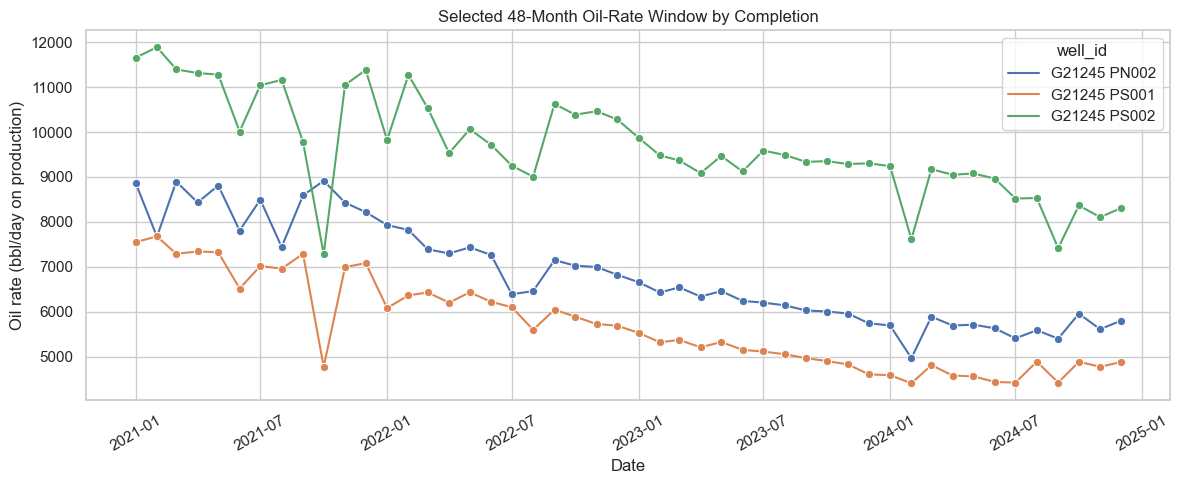

In [4]:
history_window_months = 36
internal_test_months = 6
forecast_months = 12
train_months = history_window_months - internal_test_months
selected_window_months = history_window_months + forecast_months

df = production.sort_values(["well_id", "date"]).copy()
df["days_on_prod"] = df["days_on_prod"].astype(int)
df["days_in_month"] = df["days_in_month"].astype(int)
df["oil_bbl"] = df["oil_bbl"].astype(float)
df["gas_mcf"] = df["gas_mcf"].astype(float)
df["water_bbl"] = df["water_bbl"].astype(float)

df["oil_rate_bbl_per_day"] = df["oil_bbl"] / df["days_on_prod"]
df["gas_rate_mcf_per_day"] = df["gas_mcf"] / df["days_on_prod"]
df["water_rate_bbl_per_day"] = df["water_bbl"] / df["days_on_prod"]
df["water_cut_pct"] = np.where(
    (df["oil_bbl"] + df["water_bbl"]) > 0,
    100.0 * df["water_bbl"] / (df["oil_bbl"] + df["water_bbl"]),
    0.0,
)
df["gor_mcf_per_bbl"] = np.where(df["oil_bbl"] > 0, df["gas_mcf"] / df["oil_bbl"], 0.0)
df["month_number"] = df["date"].dt.month
df["reverse_month_rank"] = df.groupby("well_id").cumcount(ascending=False) + 1
df = df.loc[df["reverse_month_rank"] <= selected_window_months].copy()
df["months_since_window_start"] = df.groupby("well_id").cumcount()
df["phase"] = np.select(
    [
        df["months_since_window_start"] < train_months,
        df["months_since_window_start"] < history_window_months,
    ],
    ["train", "test"],
    default="forecast",
)

phase_order = ["train", "test", "forecast"]
phase_summary = (
    df.groupby(["well_id", "phase"])
    .size()
    .reset_index(name="months")
)
phase_summary["phase"] = pd.Categorical(phase_summary["phase"], categories=phase_order, ordered=True)
phase_summary = phase_summary.sort_values(["well_id", "phase"]).reset_index(drop=True)
display(phase_summary)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=df, x="date", y="oil_rate_bbl_per_day", hue="well_id", marker="o", ax=ax)
ax.set_title("Selected 48-Month Oil-Rate Window by Completion")
ax.set_xlabel("Date")
ax.set_ylabel("Oil rate (bbl/day on production)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


In [5]:
def arps_hyperbolic(month_index, qi, di, b):
    return qi / np.power(1.0 + b * di * month_index, 1.0 / b)


arps_timeline = []
arps_params = []

for well_id, well_df in df.groupby("well_id"):
    well_df = well_df.sort_values("date").copy()
    train_df = well_df.loc[(well_df["phase"] == "train") & (well_df["oil_rate_bbl_per_day"] > 0)].copy()
    test_df = well_df.loc[well_df["phase"] == "test"].copy()
    forecast_df = well_df.loc[well_df["phase"] == "forecast"].copy()

    t_train = np.arange(len(train_df), dtype=float)
    y_train = train_df["oil_rate_bbl_per_day"].to_numpy(dtype=float)

    qi0 = float(max(y_train[0], 1.0))
    di0 = 0.08
    b0 = 0.7

    params, _ = curve_fit(
        arps_hyperbolic,
        t_train,
        y_train,
        p0=(qi0, di0, b0),
        bounds=([0.01, 0.0001, 0.05], [100000.0, 2.0, 1.8]),
        maxfev=20000,
    )
    qi, di, b = params

    timeline_pred = arps_hyperbolic(np.arange(len(well_df), dtype=float), qi, di, b)

    arps_params.append(
        {
            "well_id": well_id,
            "qi": qi,
            "di": di,
            "b": b,
            "training_months": len(train_df),
            "test_months": len(test_df),
            "forecast_months": len(forecast_df),
        }
    )

    for (_, row), pred in zip(well_df.iterrows(), timeline_pred):
        arps_timeline.append(
            {
                "well_id": well_id,
                "date": row["date"],
                "phase": row["phase"],
                "actual_oil_rate_bbl_per_day": row["oil_rate_bbl_per_day"],
                "actual_oil_bbl": row["oil_bbl"],
                "days_on_prod": row["days_on_prod"],
                "arps_pred_oil_rate_bbl_per_day": max(float(pred), 0.0),
                "arps_pred_oil_bbl": max(float(pred), 0.0) * row["days_on_prod"],
            }
        )

arps_params_df = pd.DataFrame(arps_params)
arps_timeline_df = pd.DataFrame(arps_timeline)
arps_forecasts_df = arps_timeline_df.loc[arps_timeline_df["phase"] == "forecast"].copy()
display(arps_params_df)
display(arps_forecasts_df.head())


,well_id,qi,di,b,training_months,test_months,forecast_months
0,G21245 PN002,8853.720217,0.011774,0.05000,30,6,12
1,G21245 PS001,7534.489932,0.013653,0.45217,30,6,12
2,G21245 PS002,11308.268680,0.008061,1.80000,30,6,12


,well_id,date,phase,actual_oil_rate_bbl_per_day,actual_oil_bbl,days_on_prod,arps_pred_oil_rate_bbl_per_day,arps_pred_oil_bbl
36,G21245 PN002,2024-01-01,forecast,5698.548387,176655.0,31,5820.505212,180435.661573
37,G21245 PN002,2024-02-01,forecast,4971.750000,139209.0,28,5753.798866,161106.368253
38,G21245 PN002,2024-03-01,forecast,5892.903226,182680.0,31,5687.894778,176324.738120
39,G21245 PN002,2024-04-01,forecast,5696.033333,170881.0,30,5622.782845,168683.485364
40,G21245 PN002,2024-05-01,forecast,5716.483871,177211.0,31,5558.453099,172312.046073


In [6]:
def build_completion_feature_frame(well_df):
    feat = well_df.sort_values("date").copy()
    base_series = {
        "oil": "oil_rate_bbl_per_day",
        "gas": "gas_rate_mcf_per_day",
        "water": "water_rate_bbl_per_day",
    }

    for prefix, column in base_series.items():
        feat[f"{prefix}_lag_1"] = feat[column].shift(1)
        feat[f"{prefix}_lag_2"] = feat[column].shift(2)
        feat[f"{prefix}_lag_3"] = feat[column].shift(3)
        feat[f"{prefix}_roll3_mean"] = feat[column].shift(1).rolling(3).mean()
        feat[f"{prefix}_roll6_mean"] = feat[column].shift(1).rolling(6).mean()

    feat["water_cut_lag_1"] = np.where(
        (feat["oil_lag_1"] + feat["water_lag_1"]) > 0,
        100.0 * feat["water_lag_1"] / (feat["oil_lag_1"] + feat["water_lag_1"]),
        np.nan,
    )
    feat["gor_lag_1"] = np.where(feat["oil_lag_1"] > 0, feat["gas_lag_1"] / feat["oil_lag_1"], np.nan)
    feat["oil_decline_1m_pct"] = np.where(
        feat["oil_lag_2"] > 0,
        100.0 * (feat["oil_lag_1"] - feat["oil_lag_2"]) / feat["oil_lag_2"],
        0.0,
    )
    return feat


def build_recursive_feature_row(histories, month_number, months_since_window_start):
    oil_history = histories["oil"]
    gas_history = histories["gas"]
    water_history = histories["water"]

    oil_lag_1, oil_lag_2, oil_lag_3 = oil_history[-1], oil_history[-2], oil_history[-3]
    gas_lag_1, gas_lag_2, gas_lag_3 = gas_history[-1], gas_history[-2], gas_history[-3]
    water_lag_1, water_lag_2, water_lag_3 = water_history[-1], water_history[-2], water_history[-3]

    liquid_lag_1 = oil_lag_1 + water_lag_1
    water_cut_lag_1 = 100.0 * water_lag_1 / liquid_lag_1 if liquid_lag_1 > 0 else 0.0
    gor_lag_1 = gas_lag_1 / oil_lag_1 if oil_lag_1 > 0 else 0.0
    oil_decline_1m_pct = 100.0 * (oil_lag_1 - oil_lag_2) / oil_lag_2 if oil_lag_2 > 0 else 0.0

    return {
        "month_number": month_number,
        "months_since_window_start": months_since_window_start,
        "oil_lag_1": oil_lag_1,
        "oil_lag_2": oil_lag_2,
        "oil_lag_3": oil_lag_3,
        "gas_lag_1": gas_lag_1,
        "gas_lag_2": gas_lag_2,
        "gas_lag_3": gas_lag_3,
        "water_lag_1": water_lag_1,
        "water_lag_2": water_lag_2,
        "water_lag_3": water_lag_3,
        "oil_roll3_mean": float(np.mean(oil_history[-3:])),
        "oil_roll6_mean": float(np.mean(oil_history[-6:])),
        "gas_roll3_mean": float(np.mean(gas_history[-3:])),
        "gas_roll6_mean": float(np.mean(gas_history[-6:])),
        "water_roll3_mean": float(np.mean(water_history[-3:])),
        "water_roll6_mean": float(np.mean(water_history[-6:])),
        "water_cut_lag_1": water_cut_lag_1,
        "gor_lag_1": gor_lag_1,
        "oil_decline_1m_pct": oil_decline_1m_pct,
    }


feature_columns = [
    "month_number",
    "months_since_window_start",
    "oil_lag_1",
    "oil_lag_2",
    "oil_lag_3",
    "gas_lag_1",
    "gas_lag_2",
    "gas_lag_3",
    "water_lag_1",
    "water_lag_2",
    "water_lag_3",
    "oil_roll3_mean",
    "oil_roll6_mean",
    "gas_roll3_mean",
    "gas_roll6_mean",
    "water_roll3_mean",
    "water_roll6_mean",
    "water_cut_lag_1",
    "gor_lag_1",
    "oil_decline_1m_pct",
]

target_columns = {
    "oil_rate_bbl_per_day": "rf_pred_oil_rate_bbl_per_day",
    "gas_rate_mcf_per_day": "rf_pred_gas_rate_mcf_per_day",
    "water_rate_bbl_per_day": "rf_pred_water_rate_bbl_per_day",
}

rf_timeline = []
rf_model_summary = []

for well_id, well_df in df.groupby("well_id"):
    feature_df = build_completion_feature_frame(well_df)
    train_feature_df = feature_df.loc[feature_df["phase"] == "train"].copy()
    train_df = train_feature_df.dropna(subset=feature_columns).copy()

    rf_models = {}
    for target_name in target_columns:
        rf_model = RandomForestRegressor(
            n_estimators=400,
            max_depth=6,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )
        rf_model.fit(train_df[feature_columns], train_df[target_name])
        rf_models[target_name] = rf_model

    train_pred_df = train_feature_df.copy()
    for prediction_column in target_columns.values():
        train_pred_df[prediction_column] = np.nan
    valid_train_mask = train_pred_df[feature_columns].notna().all(axis=1)

    for target_name, prediction_column in target_columns.items():
        train_pred_df.loc[valid_train_mask, prediction_column] = rf_models[target_name].predict(
            train_pred_df.loc[valid_train_mask, feature_columns]
        )

    future_df = feature_df.loc[feature_df["phase"].isin(["test", "forecast"])].copy().sort_values("date")
    histories = {
        "oil": feature_df.loc[feature_df["phase"] == "train", "oil_rate_bbl_per_day"].tolist(),
        "gas": feature_df.loc[feature_df["phase"] == "train", "gas_rate_mcf_per_day"].tolist(),
        "water": feature_df.loc[feature_df["phase"] == "train", "water_rate_bbl_per_day"].tolist(),
    }
    future_predictions = []

    for _, row in future_df.iterrows():
        recursive_features = build_recursive_feature_row(
            histories,
            month_number=row["month_number"],
            months_since_window_start=len(histories["oil"]),
        )
        recursive_df = pd.DataFrame([recursive_features])

        oil_pred = max(float(rf_models["oil_rate_bbl_per_day"].predict(recursive_df)[0]), 0.0)
        gas_pred = max(float(rf_models["gas_rate_mcf_per_day"].predict(recursive_df)[0]), 0.0)
        water_pred = max(float(rf_models["water_rate_bbl_per_day"].predict(recursive_df)[0]), 0.0)

        future_predictions.append(
            {
                "rf_pred_oil_rate_bbl_per_day": oil_pred,
                "rf_pred_gas_rate_mcf_per_day": gas_pred,
                "rf_pred_water_rate_bbl_per_day": water_pred,
            }
        )

        histories["oil"].append(oil_pred)
        histories["gas"].append(gas_pred)
        histories["water"].append(water_pred)

    future_pred_df = pd.concat([future_df.reset_index(drop=True), pd.DataFrame(future_predictions)], axis=1)
    combined_df = pd.concat([train_pred_df, future_pred_df], ignore_index=True).sort_values("date")
    combined_df["rf_pred_oil_rate_bbl_per_day"] = combined_df["rf_pred_oil_rate_bbl_per_day"].clip(lower=0.0)
    combined_df["rf_pred_gas_rate_mcf_per_day"] = combined_df["rf_pred_gas_rate_mcf_per_day"].clip(lower=0.0)
    combined_df["rf_pred_water_rate_bbl_per_day"] = combined_df["rf_pred_water_rate_bbl_per_day"].clip(lower=0.0)
    combined_df["rf_pred_oil_bbl"] = combined_df["rf_pred_oil_rate_bbl_per_day"] * combined_df["days_on_prod"]

    for _, row in combined_df.iterrows():
        rf_timeline.append(
            {
                "well_id": well_id,
                "date": row["date"],
                "phase": row["phase"],
                "actual_oil_rate_bbl_per_day": row["oil_rate_bbl_per_day"],
                "actual_oil_bbl": row["oil_bbl"],
                "days_on_prod": row["days_on_prod"],
                "rf_pred_oil_rate_bbl_per_day": row["rf_pred_oil_rate_bbl_per_day"],
                "rf_pred_oil_bbl": row["rf_pred_oil_bbl"],
            }
        )

    rf_model_summary.append(
        {
            "well_id": well_id,
            "training_rows": len(train_df),
            "train_fit_rows": int(valid_train_mask.sum()),
            "features_used": len(feature_columns),
            "targets_modeled": len(target_columns),
            "n_estimators": 400,
            "train_months": int((feature_df["phase"] == "train").sum()),
            "test_months": int((feature_df["phase"] == "test").sum()),
            "forecast_months": int((feature_df["phase"] == "forecast").sum()),
        }
    )

rf_timeline_df = pd.DataFrame(rf_timeline)
rf_forecasts_df = rf_timeline_df.loc[rf_timeline_df["phase"] == "forecast"].copy()
rf_model_summary_df = pd.DataFrame(rf_model_summary)
display(rf_model_summary_df)
display(rf_forecasts_df.head())


,well_id,training_rows,train_fit_rows,features_used,targets_modeled,n_estimators,train_months,test_months,forecast_months
0,G21245 PN002,24,24,20,3,400,30,6,12
1,G21245 PS001,24,24,20,3,400,30,6,12
2,G21245 PS002,24,24,20,3,400,30,6,12


,well_id,date,phase,actual_oil_rate_bbl_per_day,actual_oil_bbl,days_on_prod,rf_pred_oil_rate_bbl_per_day,rf_pred_oil_bbl
36,G21245 PN002,2024-01-01,forecast,5698.548387,176655.0,31,6510.904619,201838.043176
37,G21245 PN002,2024-02-01,forecast,4971.750000,139209.0,28,6545.868991,183284.331741
38,G21245 PN002,2024-03-01,forecast,5892.903226,182680.0,31,6513.152943,201907.741240
39,G21245 PN002,2024-04-01,forecast,5696.033333,170881.0,30,6519.956599,195598.697976
40,G21245 PN002,2024-05-01,forecast,5716.483871,177211.0,31,6509.494405,201794.326542


In [7]:
def fit_best_arima(train_series):
    candidate_orders = [
        (0, 1, 0),
        (1, 0, 0),
        (1, 1, 0),
        (0, 1, 1),
        (1, 1, 1),
        (2, 1, 0),
        (2, 1, 1),
    ]
    best_result = None
    best_order = None
    best_aic = np.inf

    for order in candidate_orders:
        try:
            result = ARIMA(train_series, order=order).fit()
            if result.aic < best_aic:
                best_aic = result.aic
                best_result = result
                best_order = order
        except Exception:
            continue

    if best_result is None:
        raise ValueError("ARIMA fitting failed for all candidate orders.")

    return best_result, best_order


es_timeline = []
arima_timeline = []
time_series_model_summary = []

for well_id, well_df in df.groupby("well_id"):
    well_df = well_df.sort_values("date").copy()
    train_df = well_df.loc[well_df["phase"] == "train"].copy()
    future_df = well_df.loc[well_df["phase"].isin(["test", "forecast"])].copy()
    train_series = train_df["oil_rate_bbl_per_day"].to_numpy(dtype=float)

    exp_model = ExponentialSmoothing(
        train_series,
        trend="add",
        seasonal=None,
        damped_trend=True,
        initialization_method="estimated",
    ).fit(optimized=True, use_brute=True)
    exp_train_pred = np.asarray(exp_model.fittedvalues, dtype=float)
    exp_future_pred = np.asarray(exp_model.forecast(len(future_df)), dtype=float)

    arima_result, arima_order = fit_best_arima(train_series)
    arima_train_pred = np.asarray(arima_result.predict(start=0, end=len(train_df) - 1), dtype=float)
    arima_future_pred = np.asarray(arima_result.forecast(len(future_df)), dtype=float)

    exp_full_pred = np.concatenate([exp_train_pred, exp_future_pred])
    arima_full_pred = np.concatenate([arima_train_pred, arima_future_pred])

    exp_full_pred = np.clip(exp_full_pred, 0.0, None)
    arima_full_pred = np.clip(arima_full_pred, 0.0, None)

    time_series_model_summary.append(
        {
            "well_id": well_id,
            "exp_smoothing_trend": "add",
            "exp_smoothing_damped": True,
            "arima_order": str(arima_order),
            "train_months": len(train_df),
            "test_months": int((well_df["phase"] == "test").sum()),
            "forecast_months": int((well_df["phase"] == "forecast").sum()),
        }
    )

    for (_, row), exp_pred, arima_pred in zip(well_df.iterrows(), exp_full_pred, arima_full_pred):
        es_timeline.append(
            {
                "well_id": well_id,
                "date": row["date"],
                "phase": row["phase"],
                "es_pred_oil_rate_bbl_per_day": float(exp_pred),
                "es_pred_oil_bbl": float(exp_pred) * row["days_on_prod"],
            }
        )
        arima_timeline.append(
            {
                "well_id": well_id,
                "date": row["date"],
                "phase": row["phase"],
                "arima_pred_oil_rate_bbl_per_day": float(arima_pred),
                "arima_pred_oil_bbl": float(arima_pred) * row["days_on_prod"],
            }
        )

es_timeline_df = pd.DataFrame(es_timeline)
arima_timeline_df = pd.DataFrame(arima_timeline)
time_series_model_summary_df = pd.DataFrame(time_series_model_summary)
display(time_series_model_summary_df)
display(es_timeline_df.head())
display(arima_timeline_df.head())


,well_id,exp_smoothing_trend,exp_smoothing_damped,arima_order,train_months,test_months,forecast_months
0,G21245 PN002,add,True,"(1, 1, 0)",30,6,12
1,G21245 PS001,add,True,"(0, 1, 1)",30,6,12
2,G21245 PS002,add,True,"(1, 1, 1)",30,6,12


,well_id,date,phase,es_pred_oil_rate_bbl_per_day,es_pred_oil_bbl
0,G21245 PN002,2021-01-01,train,8391.281320,260129.720907
1,G21245 PN002,2021-02-01,train,8513.683877,238383.148555
2,G21245 PN002,2021-03-01,train,8172.430195,253345.336050
3,G21245 PN002,2021-04-01,train,8373.955391,251218.661733
4,G21245 PN002,2021-05-01,train,8357.340466,259077.554437


,well_id,date,phase,arima_pred_oil_rate_bbl_per_day,arima_pred_oil_bbl
0,G21245 PN002,2021-01-01,train,0.000000,0.000000
1,G21245 PN002,2021-02-01,train,7833.782067,219345.897875
2,G21245 PN002,2021-03-01,train,8313.233221,257710.229855
3,G21245 PN002,2021-04-01,train,8242.225327,247266.759808
4,G21245 PN002,2021-05-01,train,8682.189829,269147.884689


,phase,model,MAE,RMSE,MAPE_pct
0,forecast,Arps hyperbolic,320.857,436.146,5.274
1,forecast,Random forest (multivariate),989.097,1096.554,16.443
2,forecast,Exponential smoothing,466.157,550.752,7.680
3,forecast,ARIMA,917.121,1049.665,14.629
4,test,Arps hyperbolic,142.595,179.728,1.998
5,test,Random forest (multivariate),566.443,607.036,9.154
6,test,Exponential smoothing,151.640,214.694,1.903
7,test,ARIMA,369.231,410.588,5.827


,well_id,phase,model,MAE,RMSE,MAPE_pct
0,G21245 PN002,forecast,Arps hyperbolic,302.800,400.283,5.433
1,G21245 PN002,forecast,Random forest (multivariate),956.737,989.049,17.271
2,G21245 PN002,forecast,Exponential smoothing,343.409,432.182,6.138
3,G21245 PN002,forecast,ARIMA,703.518,746.942,12.764
4,G21245 PN002,test,Arps hyperbolic,46.784,65.453,0.792
5,G21245 PN002,test,Random forest (multivariate),615.354,653.001,10.320
6,G21245 PN002,test,Exponential smoothing,36.218,46.952,0.614
7,G21245 PN002,test,ARIMA,307.198,338.164,5.166
8,G21245 PS001,forecast,Arps hyperbolic,253.683,319.362,5.361
9,G21245 PS001,forecast,Random forest (multivariate),782.337,804.144,17.039


,well_id,date,phase,actual_oil_rate_bbl_per_day,actual_oil_bbl,days_on_prod,arps_pred_oil_rate_bbl_per_day,arps_pred_oil_bbl,rf_pred_oil_rate_bbl_per_day,rf_pred_oil_bbl,es_pred_oil_rate_bbl_per_day,es_pred_oil_bbl,arima_pred_oil_rate_bbl_per_day,arima_pred_oil_bbl
36,G21245 PN002,2024-01-01,forecast,5698.548387,176655.0,31,5820.505212,180435.661573,6510.904619,201838.043176,5773.523949,178979.242429,6320.973580,195950.180969
37,G21245 PN002,2024-02-01,forecast,4971.750000,139209.0,28,5753.798866,161106.368253,6545.868991,183284.331741,5704.803255,159734.491132,6319.514412,176946.403543
38,G21245 PN002,2024-03-01,forecast,5892.903226,182680.0,31,5687.894778,176324.738120,6513.152943,201907.741240,5636.766331,174739.756262,6320.295138,195929.149288
39,G21245 PN002,2024-04-01,forecast,5696.033333,170881.0,30,5622.782845,168683.485364,6519.956599,195598.697976,5569.406375,167082.191241,6319.877412,189596.322349
40,G21245 PN002,2024-05-01,forecast,5716.483871,177211.0,31,5558.453099,172312.046073,6509.494405,201794.326542,5502.716650,170584.216149,6320.100916,195923.128393
41,G21245 PN002,2024-06-01,forecast,5634.966667,169049.0,30,5494.895701,164846.871027,6508.015953,195240.478582,5436.690488,163100.714640,6319.981330,189599.439905
42,G21245 PN002,2024-07-01,forecast,5411.129032,167745.0,31,5432.100942,168395.129198,6506.569385,201703.650930,5371.321286,166510.959876,6320.045314,195921.404746
43,G21245 PN002,2024-08-01,forecast,5592.931034,162195.0,29,5370.059241,155731.717980,6511.271674,188826.878542,5306.602508,153891.472738,6320.011080,183280.321311
44,G21245 PN002,2024-09-01,forecast,5404.444444,145920.0,27,5308.761142,143336.550827,6672.397433,180154.730701,5242.527682,141548.247412,6320.029397,170640.793717


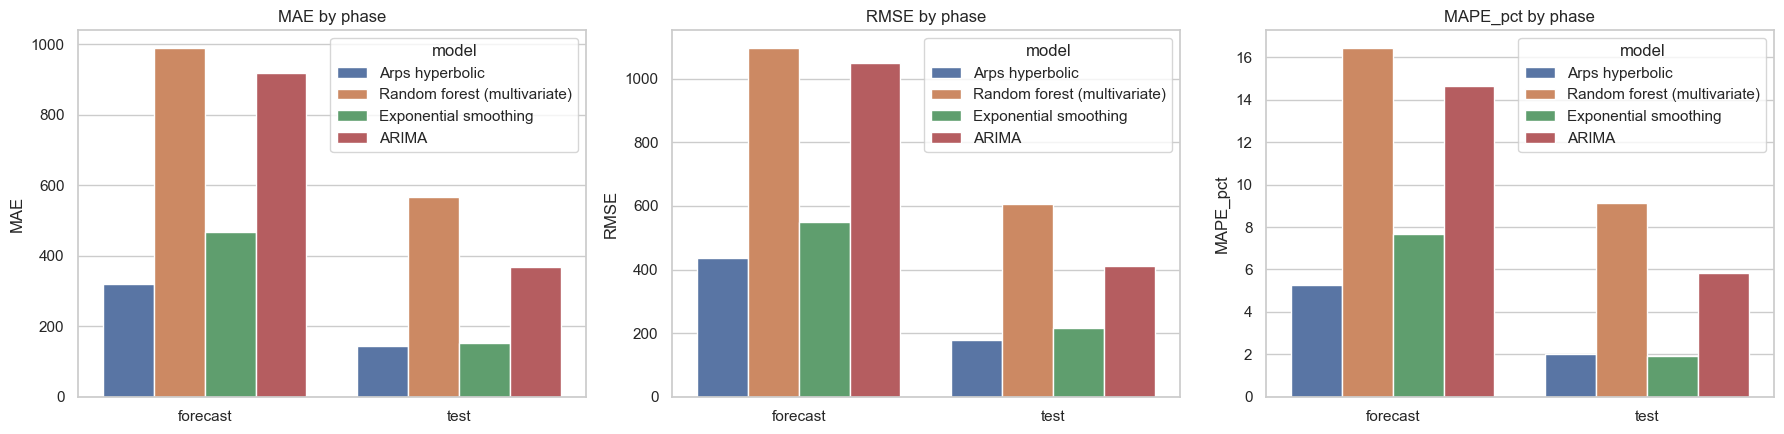

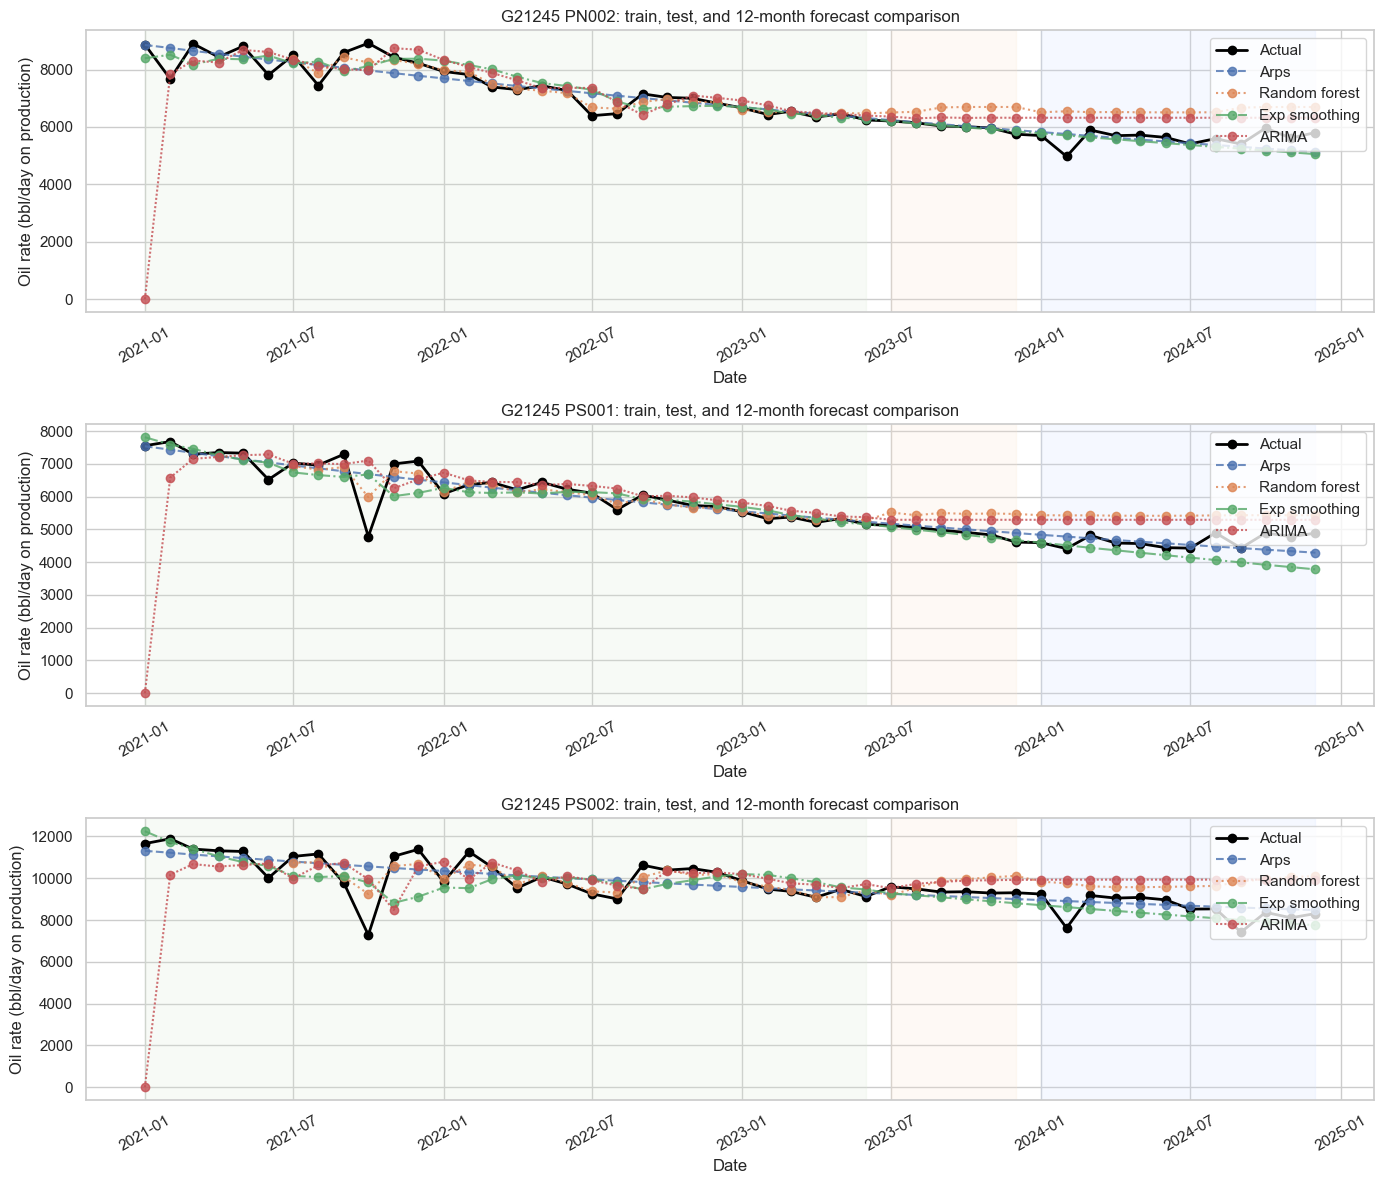

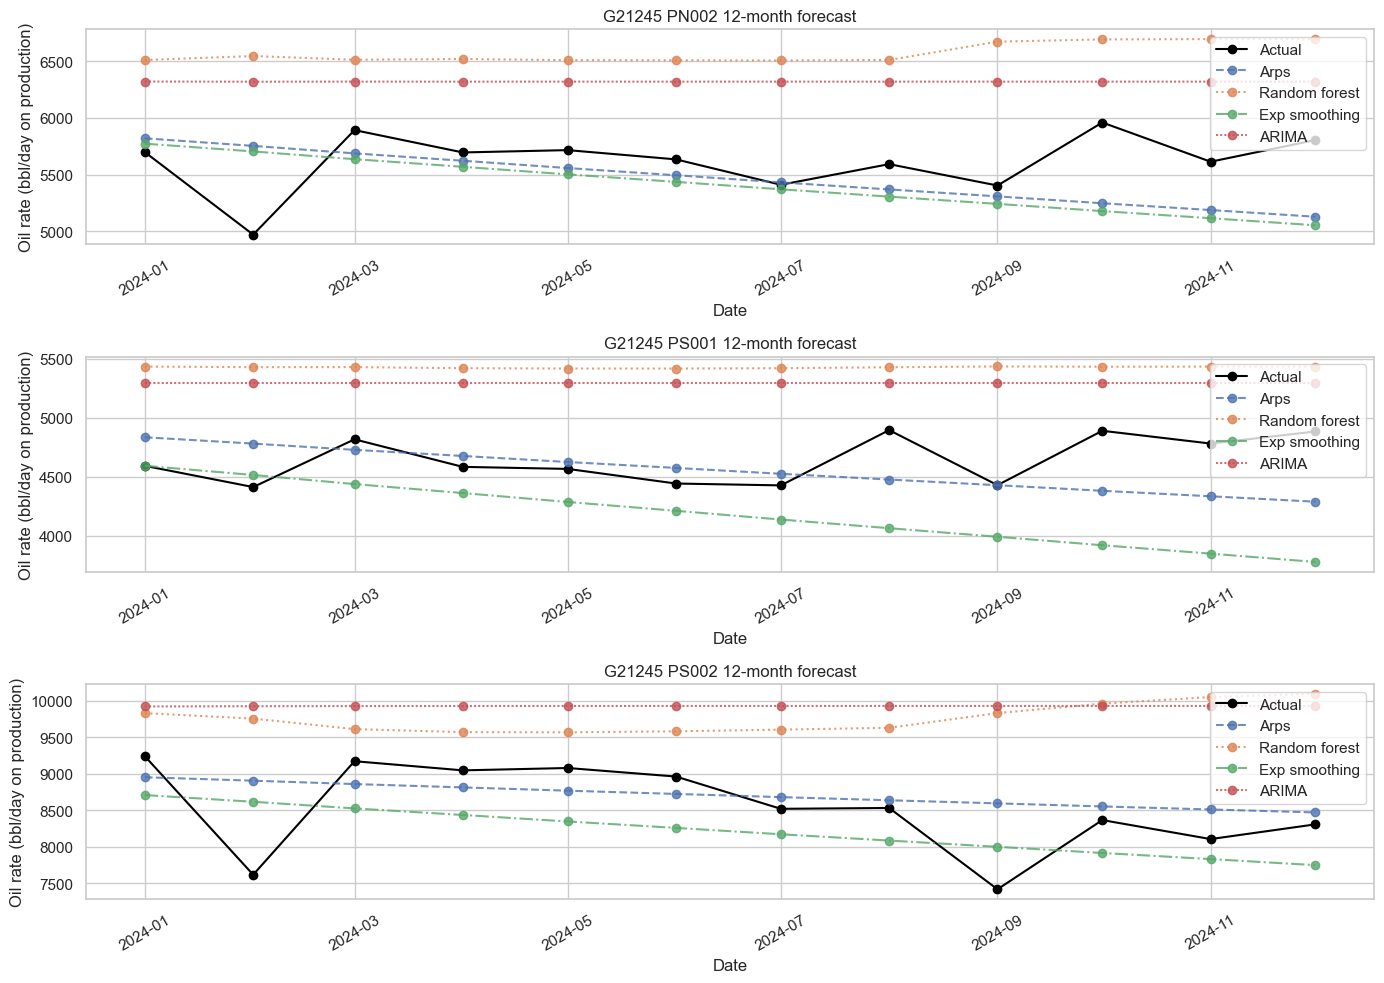

In [8]:
timeline_compare = arps_timeline_df.merge(
    rf_timeline_df[["well_id", "date", "phase", "rf_pred_oil_rate_bbl_per_day", "rf_pred_oil_bbl"]],
    on=["well_id", "date", "phase"],
    how="inner",
)

timeline_compare = timeline_compare.merge(
    es_timeline_df[["well_id", "date", "phase", "es_pred_oil_rate_bbl_per_day", "es_pred_oil_bbl"]],
    on=["well_id", "date", "phase"],
    how="inner",
)

timeline_compare = timeline_compare.merge(
    arima_timeline_df[["well_id", "date", "phase", "arima_pred_oil_rate_bbl_per_day", "arima_pred_oil_bbl"]],
    on=["well_id", "date", "phase"],
    how="inner",
)


def safe_mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    mask = actual > 0
    if not mask.any():
        return np.nan
    return 100.0 * np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask]))


model_specs = [
    ("Arps hyperbolic", "arps_pred_oil_rate_bbl_per_day"),
    ("Random forest (multivariate)", "rf_pred_oil_rate_bbl_per_day"),
    ("Exponential smoothing", "es_pred_oil_rate_bbl_per_day"),
    ("ARIMA", "arima_pred_oil_rate_bbl_per_day"),
]

evaluation_df = timeline_compare.loc[timeline_compare["phase"].isin(["test", "forecast"])].copy()
forecast_compare = timeline_compare.loc[timeline_compare["phase"] == "forecast"].copy()

phase_metrics = []
for phase_name, phase_df in evaluation_df.groupby("phase"):
    for model_name, prediction_column in model_specs:
        model_phase_df = phase_df.dropna(subset=[prediction_column])
        phase_metrics.append(
            {
                "phase": phase_name,
                "model": model_name,
                "MAE": mean_absolute_error(model_phase_df["actual_oil_rate_bbl_per_day"], model_phase_df[prediction_column]),
                "RMSE": mean_squared_error(model_phase_df["actual_oil_rate_bbl_per_day"], model_phase_df[prediction_column], squared=False),
                "MAPE_pct": safe_mape(model_phase_df["actual_oil_rate_bbl_per_day"], model_phase_df[prediction_column]),
            }
        )
overall_metrics = pd.DataFrame(phase_metrics).round(3)

per_completion_metrics = []
for (well_id, phase_name), well_df in evaluation_df.groupby(["well_id", "phase"]):
    for model_name, prediction_column in model_specs:
        model_well_df = well_df.dropna(subset=[prediction_column])
        per_completion_metrics.append(
            {
                "well_id": well_id,
                "phase": phase_name,
                "model": model_name,
                "MAE": mean_absolute_error(model_well_df["actual_oil_rate_bbl_per_day"], model_well_df[prediction_column]),
                "RMSE": mean_squared_error(model_well_df["actual_oil_rate_bbl_per_day"], model_well_df[prediction_column], squared=False),
                "MAPE_pct": safe_mape(model_well_df["actual_oil_rate_bbl_per_day"], model_well_df[prediction_column]),
            }
        )
per_well_metrics_df = pd.DataFrame(per_completion_metrics).round(3)

display(overall_metrics)
display(per_well_metrics_df)
display(forecast_compare.head(9))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, metric_name in zip(axes, ["MAE", "RMSE", "MAPE_pct"]):
    sns.barplot(data=overall_metrics, x="phase", y=metric_name, hue="model", ax=ax)
    ax.set_title(f"{metric_name} by phase")
    ax.set_xlabel("")
    ax.set_ylabel(metric_name)
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

phase_colors = {"train": "#d9ead3", "test": "#fce5cd", "forecast": "#d0e0ff"}
model_styles = {
    "arps_pred_oil_rate_bbl_per_day": {"label": "Arps", "linestyle": "--", "marker": "o"},
    "rf_pred_oil_rate_bbl_per_day": {"label": "Random forest", "linestyle": ":", "marker": "o"},
    "es_pred_oil_rate_bbl_per_day": {"label": "Exp smoothing", "linestyle": "-.", "marker": "o"},
    "arima_pred_oil_rate_bbl_per_day": {"label": "ARIMA", "linestyle": (0, (1, 1)), "marker": "o"},
}

fig, axes = plt.subplots(len(timeline_compare["well_id"].unique()), 1, figsize=(14, 12), sharex=False)
if len(timeline_compare["well_id"].unique()) == 1:
    axes = [axes]

for ax, (well_id, well_df) in zip(axes, timeline_compare.groupby("well_id")):
    well_df = well_df.sort_values("date")
    for phase_name, phase_df in well_df.groupby("phase"):
        ax.axvspan(phase_df["date"].min(), phase_df["date"].max(), color=phase_colors[phase_name], alpha=0.2)
    ax.plot(well_df["date"], well_df["actual_oil_rate_bbl_per_day"], color="black", linewidth=2, marker="o", label="Actual")
    for prediction_column, style in model_styles.items():
        ax.plot(
            well_df["date"],
            well_df[prediction_column],
            linestyle=style["linestyle"],
            marker=style["marker"],
            alpha=0.8,
            label=style["label"],
        )
    ax.set_title(f"{well_id}: train, test, and 12-month forecast comparison")
    ax.set_xlabel("Date")
    ax.set_ylabel("Oil rate (bbl/day on production)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(forecast_compare["well_id"].unique()), 1, figsize=(14, 10), sharex=False)
if len(forecast_compare["well_id"].unique()) == 1:
    axes = [axes]

for ax, (well_id, well_df) in zip(axes, forecast_compare.groupby("well_id")):
    well_df = well_df.sort_values("date")
    ax.plot(well_df["date"], well_df["actual_oil_rate_bbl_per_day"], color="black", marker="o", label="Actual")
    for prediction_column, style in model_styles.items():
        ax.plot(
            well_df["date"],
            well_df[prediction_column],
            linestyle=style["linestyle"],
            marker=style["marker"],
            alpha=0.8,
            label=style["label"],
        )
    ax.set_title(f"{well_id} 12-month forecast")
    ax.set_xlabel("Date")
    ax.set_ylabel("Oil rate (bbl/day on production)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


## Interpretation

Use the outputs like this in class:
- The shaded timeline plots show how each model behaves on the `30-month` training segment, the `6-month` internal test segment, and the `12-month` forward forecast.
- `oil_bbl` is a monthly volume in `bbl/month`, while the plotted target is `oil_rate_bbl_per_day` in `bbl/day on production` using `days_on_prod` from the BSEE records.
- `Arps` gives a familiar petroleum-engineering baseline based on decline behavior.
- The upgraded `RandomForestRegressor` uses a richer production-state description by learning from oil, gas, and water behavior rather than oil-rate lags alone.
- `Exponential Smoothing` and `ARIMA` give pure time-series baselines that help distinguish pattern-following statistical forecasts from physics-inspired decline analysis.
- Because all four models are trained completion by completion, the comparison is stricter and easier to explain.
- If `Arps` remains competitive, that reinforces why decline-curve methods remain valuable screening tools even after adding stronger data-driven baselines.

This is still a classroom example. A field deployment would need better operational context, stronger QA, and a more formal validation process.

In [9]:
if data_dir.name == "production_forecasting" and data_dir.parent.name == "sample-data" and data_dir.parent.parent.name == "training":
    results_dir = data_dir.parent.parent.parent / "results" / "production_forecasting"
else:
    results_dir = Path.cwd() / "results" / "production_forecasting"
results_dir.mkdir(parents=True, exist_ok=True)

overall_metrics.to_csv(results_dir / "model_comparison_metrics.csv", index=False)
per_well_metrics_df.to_csv(results_dir / "per_completion_metrics.csv", index=False)
per_well_metrics_df.to_csv(results_dir / "per_well_metrics.csv", index=False)
forecast_compare.to_csv(results_dir / "holdout_forecasts.csv", index=False)
timeline_compare.to_csv(results_dir / "prediction_timeline.csv", index=False)
arps_params_df.to_csv(results_dir / "arps_parameters.csv", index=False)
rf_model_summary_df.to_csv(results_dir / "rf_model_summary.csv", index=False)
time_series_model_summary_df.to_csv(results_dir / "time_series_model_summary.csv", index=False)

print(f"Results written to: {results_dir}")


Results written to: /Users/davidnnamdi/python ml generative AI training/results/production_forecasting
